# Tarea 3 — Machine learning
**Autor:** Matías Arriagada R. | 2022445068 | matiaarriagada2022@udec.cl
**Curso:** Data analysis and machine learning — Noveno semestre
**Fecha:** Junio 2026
**Profesor:** Juan Carlos Caro S.

---

ESte notebook es la tarea solicitada, parte de las preguntas a responder se encuentran a continuación:

**Índice**
1. Carga, limpieza y estadística descriptiva
2. Análisis Factorial Exploratorio (EFA) sobre `sk1`–`sk13`
3. Análisis Factorial Confirmatorio (CFA) y guardado de predicciones
4. Random Forest para clasificar `madre_work`
5. Comparación XGBoost vs SVM vs Stacking
6. Clustering sobre IMCE y actividad física
7. Re-estimación del mejor modelo en el grupo de mayor IMCE
8. Procesamiento de Lenguaje Natural (NLP) sobre `narrative`


## 0. Configuración del entorno

Realizamos la instalación de librerias, la mayoría son coumnes, se incluye la semilla 42 para repricidad del proyecto. Recomiendo usar !pip install para las dependencias.

In [23]:
# Si alguna librería no está instalada, descomente la siguiente línea:
# !pip install pandas numpy scipy scikit-learn matplotlib seaborn factor_analyzer xgboost nltk wordcloud

import warnings
warnings.filterwarnings('ignore')

import re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
print('Entorno listo. numpy', np.__version__, '| pandas', pd.__version__)

Entorno listo. numpy 1.26.4 | pandas 2.3.3


In [24]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Carga, limpieza y estadística descriptiva

Cargamos la base de datos, identificar los tipos de datos, tratar valores faltantes, recodificar
variables inconsistentes, detectar outliers y describir las variables relevantes.

*Se considera que la persona que vaya a cargar este archivo va a tener los datos en la misma carpeta*

## Diccionario de las variables
- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: nunca - 5: siempre)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica del estudiante (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)
- narrative: (Generated) narrative text based on sk1-sk13.

In [25]:
df = pd.read_csv('junaeb2n.csv')
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (41854, 24)


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,2.0,1,16.0,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1.0,1,17.0,15,0,"Exhibe un perfil socioemocional muy solido, de..."


### 1.1 Tipos de datos y estructura general

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int64  
 18  act_fisica  40419 non-null  float64
 19  area        41854 non-nul

<Axes: >

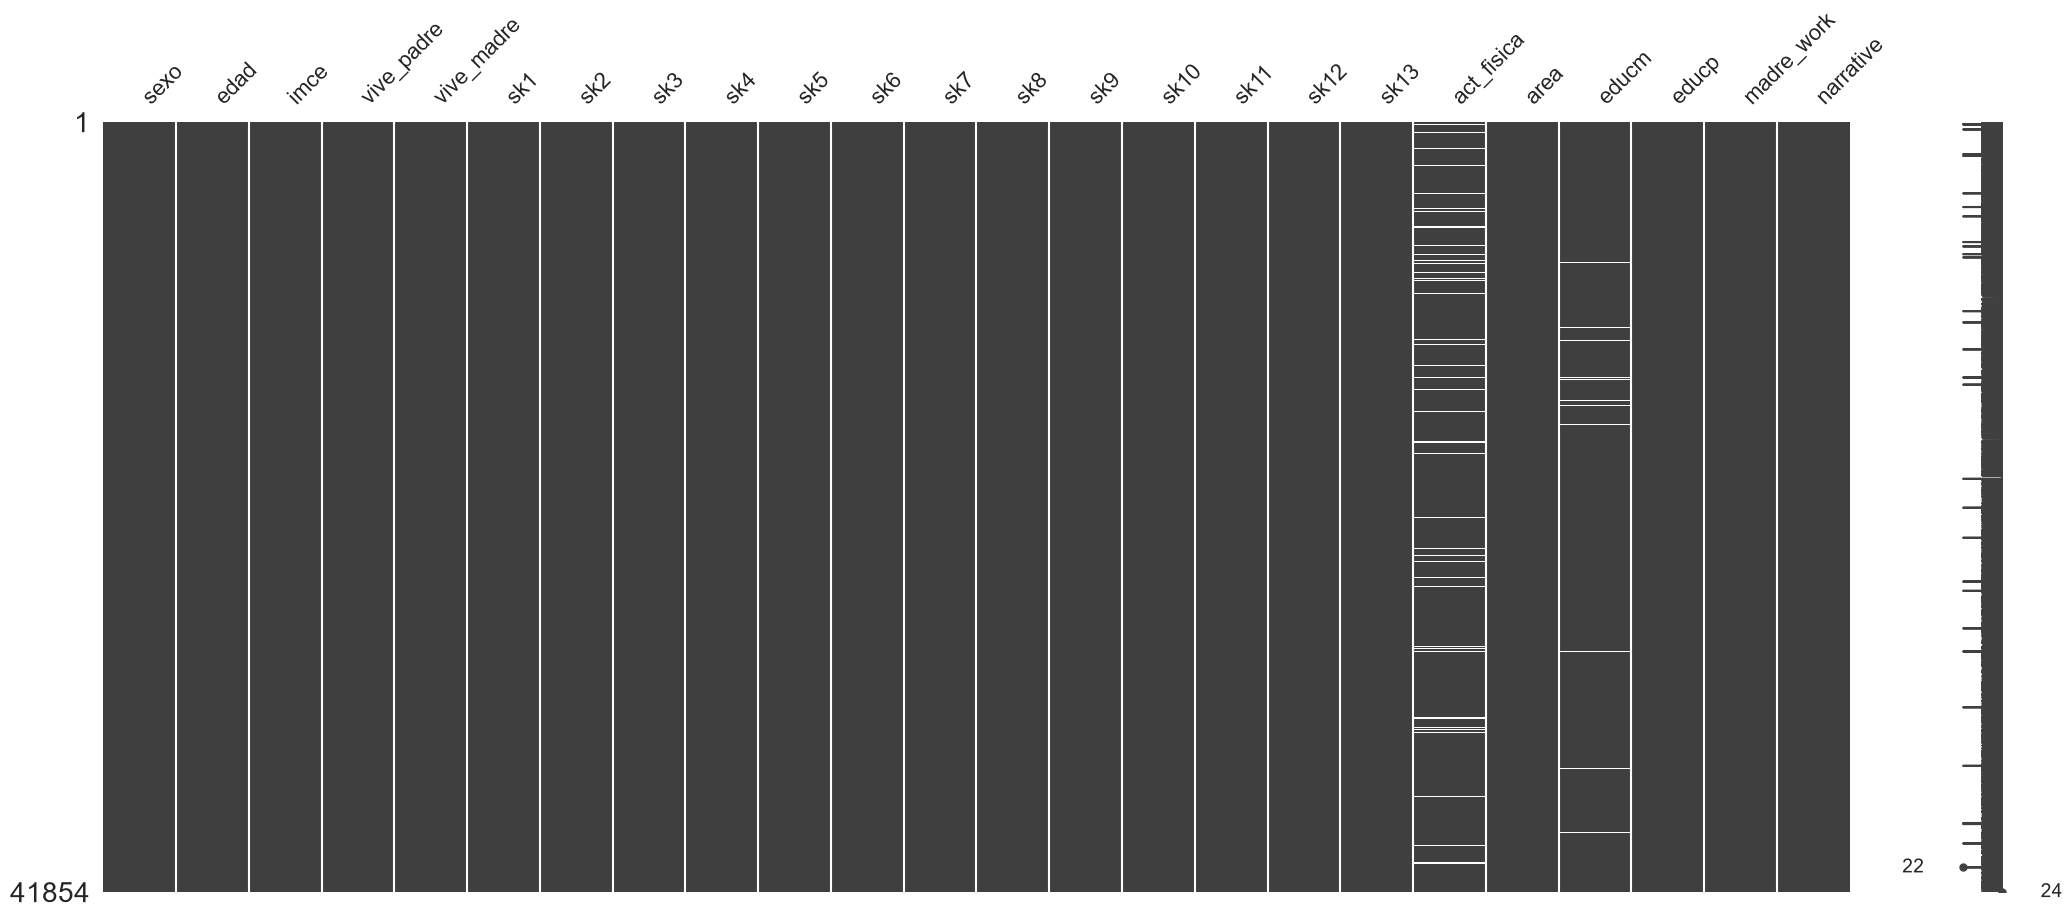

In [26]:
df.info()
#Utilizaremos missingno para visualizar los valores nulos en el dataset
msno.matrix(df)

Observamos que dentro de la columna de actividad fisica y educm faltan datos, a priori, podemos decir que son pocos datos. Los cuales podemos imputar con la mediana o la media. Pero nos impidirá poder realizar un analisis estadístico como variable dependiente más adelante.

Clasificamos conceptualmente las variables según el diccionario de datos:

- Binarias/categóricas: `sexo`, `area`, `vive_padre`, `vive_madre`, `madre_work`
- Ordinales (escala 1–5): `sk1`–`sk13`, `act_fisica`
- Numéricas continuas / de conteo: `edad` (meses), `imce` (puntaje z), `educm`, `educp` (años)
- Texto: `narrative` (descripción generada a partir de `sk1`–`sk13`)

In [27]:
# Nombramos las variables según su tipo de dato, para luego poder tratarlas de manera más sencilla.
sk_cols = [f'sk{i}' for i in range(1, 14)]
binarias   = ['sexo', 'area', 'vive_padre', 'vive_madre', 'madre_work']
ordinales  = sk_cols + ['act_fisica']
continuas  = ['edad', 'imce', 'educm', 'educp']
texto      = ['narrative']

for nombre, grupo in [('Binarias/categóricas', binarias), ('Ordinales', ordinales),
                      ('Continuas', continuas), ('Texto', texto)]:
    print(f'{nombre:22s}: {grupo}')

Binarias/categóricas  : ['sexo', 'area', 'vive_padre', 'vive_madre', 'madre_work']
Ordinales             : ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13', 'act_fisica']
Continuas             : ['edad', 'imce', 'educm', 'educp']
Texto                 : ['narrative']


### 1.2 Revisamos los datos faltantes.

Revisamos la cantidad y el porcentaje de datos faltantes por columna. (podemos usar la media y mediana para poder rellenar como mencionamos anteriormente).

            faltantes     %
act_fisica       1435  3.43
educm             551  1.32


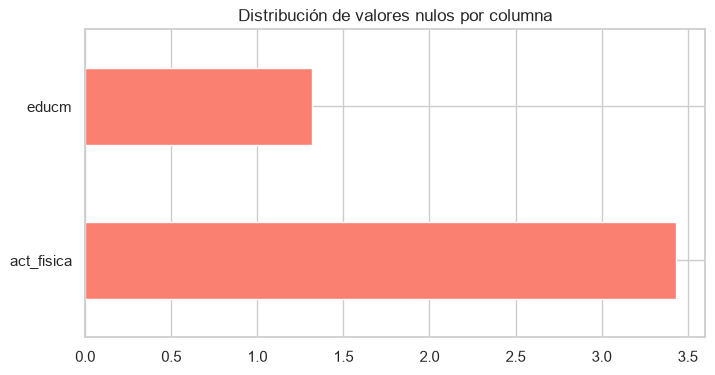

In [28]:
na = df.isna().sum()
na = na[na > 0].to_frame('faltantes')
na['%'] = (100 * na['faltantes'] / len(df)).round(2)
na
#Añadimos la distribución de los valores nulos por columna, para ver si hay alguna que tenga un porcentaje alto de valores nulos y que pueda ser eliminada del dataset.
na['%'].plot.barh(figsize=(8, 4), title='Distribución de valores nulos por columna', color='salmon')
print(na.sort_values('%', ascending=False).head(10))
#Realizamos la visualización de la distribución de los valores nulos por columna, para ver si hay alguna que tenga un porcentaje alto de valores nulos y que pueda ser eliminada del dataset.
#Veemos el gráfico de distribución de valores nulos por columna, para ver si hay alguna que tenga un porcentaje alto de valores nulos y que pueda ser eliminada del dataset.

Solo `act_fisica` (~3,4 %) y `educm` (~1,3 %) tienen faltantes, y en proporción baja. Como
eliminar filas descartaría información útil, **imputamos**:

- `act_fisica` es **ordinal** → imputamos con la **mediana** (valor central robusto en una escala 1–5).
- `educm` es numérica (años) → imputamos con la **mediana** (robusta frente a sesgo/outliers).

In [29]:
df['act_fisica'] = df['act_fisica'].fillna(df['act_fisica'].median())
df['educm']      = df['educm'].fillna(df['educm'].median())
print('Faltantes restantes:', int(df.isna().sum().sum()))

Faltantes restantes: 0


### 1.3 Recodificación de variables inconsistentes
Revisando dentro de los datos, podemos visualizar que parte de estos de estos datos pueden ser trtatados a nuestra conveniencia. Dado la finalidad de la tarea se puede reeemplazar (lo correcto sería crear una nueva columna), pero dado que nos interesa ver la presencia de los progenitores, solo los dejamos en replace.

El diccionario indica que `vive_padre`/`vive_madre` valen 1 si el progenitor vive en el hogar, pero
existe además un código `2` ("más de un padre/madre"). Para usarlas como **indicador binario de
presencia**, recodificamos `2 → 1` (vive en el hogar).

In [30]:
print('Antes :', dict(df['vive_padre'].value_counts()), '|', dict(df['vive_madre'].value_counts()))
df['vive_padre'] = df['vive_padre'].replace({2: 1})
df['vive_madre'] = df['vive_madre'].replace({2: 1})
print('Después:', dict(df['vive_padre'].value_counts()), '|', dict(df['vive_madre'].value_counts()))

Antes : {1: 30105, 0: 11733, 2: 16} | {1: 40255, 0: 1529, 2: 70}
Después: {1: 30121, 0: 11733} | {1: 40325, 0: 1529}


### 1.4 Estadística descriptiva

In [31]:
df[continuas + ['act_fisica']].describe().round(2)

,edad,imce,educm,educp,act_fisica
count,41854.00,41854.00,41854.00,41854.00,41854.00
mean,83.07,1.01,12.98,12.90,2.53
std,3.99,1.38,3.35,3.46,1.06
min,62.00,-5.02,0.00,0.00,1.00
25%,81.00,0.10,11.00,11.00,2.00
50%,82.00,0.97,13.00,13.00,2.00
75%,84.00,1.93,15.00,14.00,3.00
max,107.00,5.04,22.00,22.00,5.00


### 1.5 Distribuciones de las variables continuas y detección de *outliers*

Para imce (puntaje z estandarizado) y edad graficamos histograma + boxplot. Usamos la regla |z| > 3 para cuantificar valores extremos: en una variable ya estandarizada como imce estos son plausibles (extremos reales), por lo que no se eliminan, solo se documentan. Es importante después identificar estos datos para tener esto a consideración para evitarlo usarlo en algo.

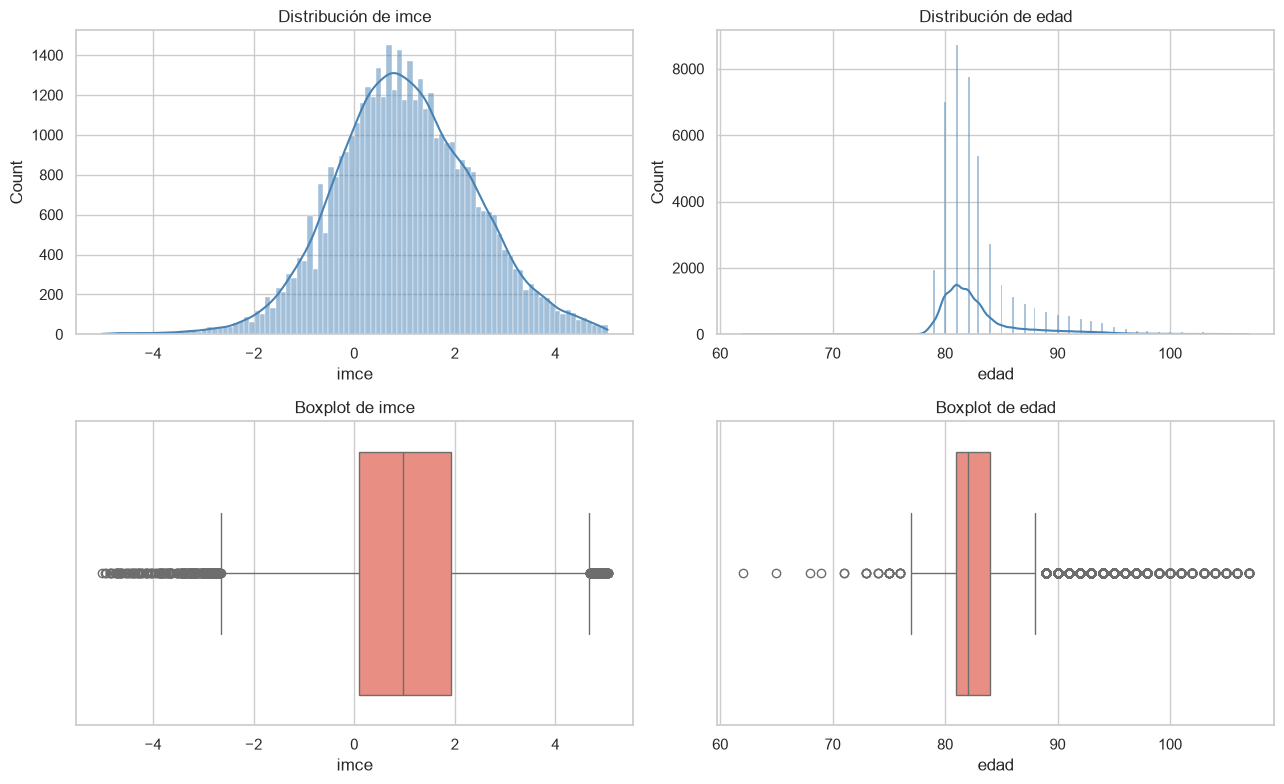

Valores con |z|>3 en imce: 144 (0.34%) → extremos válidos, se conservan


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes[0], ['imce', 'edad']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue'); ax.set_title(f'Distribución de {col}')
for ax, col in zip(axes[1], ['imce', 'edad']):
    sns.boxplot(x=df[col], ax=ax, color='salmon'); ax.set_title(f'Boxplot de {col}')
plt.tight_layout(); plt.show()

z = np.abs(stats.zscore(df['imce']))
print(f'Valores con |z|>3 en imce: {(z > 3).sum()} ({100*(z>3).mean():.2f}%) → extremos válidos, se conservan')

### 1.6 Distribuciones de variables categóricas y ordinales
Usamos la visualización de variables demográficas e identificar parte de los argumentos en los datos.

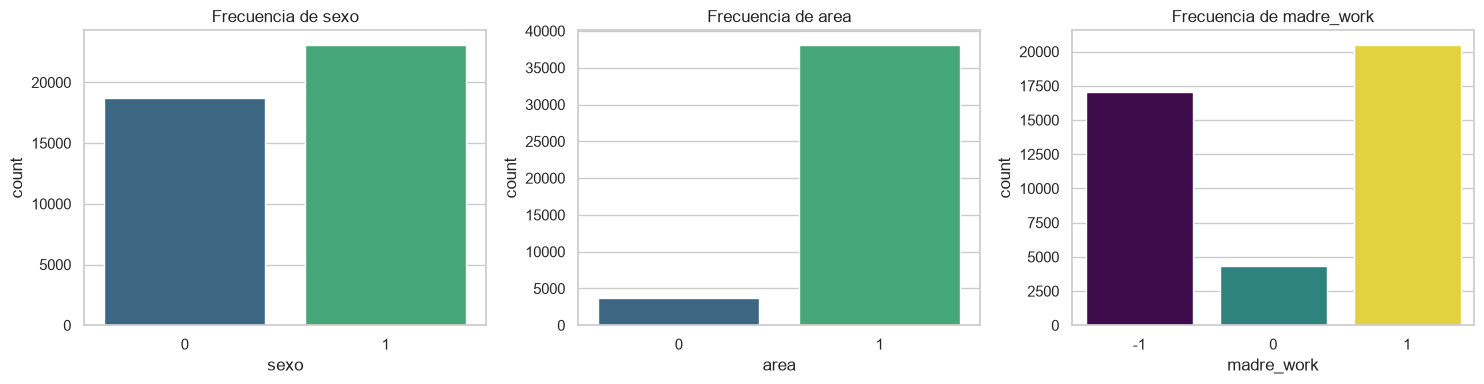

madre_work (target de P4/P5):
madre_work
1 empleada            20519
-1 labor doméstica    17026
0 desempleada          4309
Name: count, dtype: int64


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['sexo', 'area', 'madre_work']):
    sns.countplot(x=df[col], ax=ax, hue=df[col], legend=False, palette='viridis')
    ax.set_title(f'Frecuencia de {col}')
plt.tight_layout(); plt.show()

print('madre_work (target de P4/P5):')
print(df['madre_work'].value_counts().rename({-1: '-1 labor doméstica', 0: '0 desempleada', 1: '1 empleada'}))

Conclusión: La base quedó limpia: sin faltantes, con `vve_*` recodificadas y los tipos identificados. La variable objetivo `madre_work` está desbalanceada hacia las categorías `1` (empleada) y `-1` (labor doméstica); la categoría `0` (desempleada) es minoritaria, lo que motiva su exclusión en las Preguntas 4 y 5.

## 2. Análisis Factorial Exploratorio (EFA) sobre `sk1`–`sk13`

Veremos como se comportan los factores latentes en estas 13 habilidades.

### 2.1 Alineación de la polaridad de los ítems
El EFA exige que todos los ítems apunten en el mismo sentido logico. En la escala original (1 = siempre … 5 = nunca) en una escala likeert un valor bajo indica la conducta positiva frecuente.

 La única conducta **negativa** es `sk7` (*es agresivo*, 1 = nunca … 5 = siempre), que está invertida respecto del resto. La recodificamos con `6 - sk7` para que, igual que los demás ítems, **un valor bajo represente
el aspecto positivo** (poca agresividad).

In [34]:
# Realizaremos la conversión de los ítems de la escala de agresividad (sk1 a sk13) a una escala de 1 a 5, donde 1 es "totalmente en desacuerdo" y 5 es "totalmente de acuerdo". Además, invertiremos el ítem negativo (sk7) para que todos los ítems queden en el mismo sentido.
from factor_analyzer import (FactorAnalyzer, calculate_kmo,
                             calculate_bartlett_sphericity)

X_efa = df[sk_cols].copy()
X_efa['sk7'] = 6 - X_efa['sk7']   # invertir el ítem negativo (agresividad)
print('sk7 recodificado (6 - sk7). Todos los ítems quedan en el mismo sentido.')

sk7 recodificado (6 - sk7). Todos los ítems quedan en el mismo sentido.


### 2.2 ¿Son los datos adecuados para un análisis factorial?
Dos pruebas estándar:
- **Test de esfericidad de Bartlett:** la hipótesis nula es que la matriz de correlación es la identidad (variables no correlacionadas). Un *p-value* ≈ 0 la rechaza → Esto quiere decir que si hay estructura para poder ser algo factorizable.
- **KMO (Kaiser-Meyer-Olkin):** mide qué proporción de la varianza es común. KMO > 0,8 se considera "meritorio". *la Prueba KMO es una forma de cuantificar el grado de interrelaciones entre variables. Un valor de KMO más cercano a 1 sugiere que un análisis factorial puede resultar útil con sus datos. Si el valor es inferior a 0,5, es probable que los resultados del análisis factorial sean deficientes.* Fuente: https://fastercapital.com/es/contenido/Kaiser-Meyer-Olkin--KMO--Prueba--Evaluacion-de-la-adecuacion-de-la-muestra--La-prueba-KMO-en-el-analisis-factorial.html

In [35]:
#Realizamos el test de esfericidad de Bartlett y el test KMO para evaluar la adecuación de los datos para el análisis factorial.
chi2, p_value = calculate_bartlett_sphericity(X_efa)
kmo_all, kmo_model = calculate_kmo(X_efa)
print(f'Bartlett: chi2={chi2:.0f}, p-value={p_value:.3g}  ->  {"adecuado" if p_value < 0.05 else "no adecuado"}')
print(f'KMO global = {kmo_model:.3f}  ->  {"meritorio" if kmo_model > 0.8 else "aceptable"}')

Bartlett: chi2=122117, p-value=0  ->  adecuado
KMO global = 0.873  ->  meritorio


Por lo tanto decimos que los datos si poseen estructura para poder trabajarlos, si no, no habria trabajo xd.

### 2.3 Número óptimo de factores
Ajustamos un modelo sin rotación con tantos factores como variables y revisamos los **autovalores
(eigenvalues)**. El **criterio de Kaiser** retiene los factores con autovalor > 1; el **gráfico de
sedimentación (scree plot)** ayuda visualmente a ver el "codo".

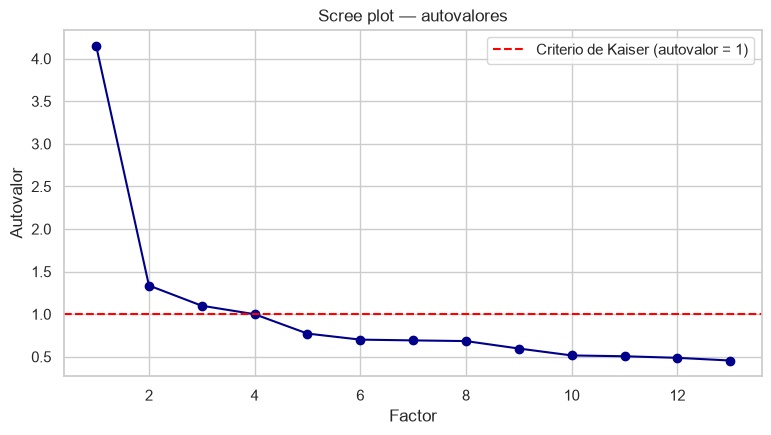

Autovalores > 1: [4.154 1.337 1.099] -> 3 factores


In [36]:
fa_all = FactorAnalyzer(n_factors=len(sk_cols), rotation=None)
fa_all.fit(X_efa)
ev, _ = fa_all.get_eigenvalues()
n_factores = int((ev > 1).sum())

plt.figure(figsize=(9, 4.5))
plt.plot(range(1, len(ev) + 1), ev, 'o-', color='darkblue')
plt.axhline(1, color='red', ls='--', label='Criterio de Kaiser (autovalor = 1)')
plt.title('Scree plot — autovalores'); plt.xlabel('Factor'); plt.ylabel('Autovalor')
plt.legend(); plt.show()
print('Autovalores > 1:', np.round(ev[ev > 1], 3), '->', n_factores, 'factores')

### 2.4 Factor loadings (rotación promax)
Realizamos con un mapa de calor, la visualización de variables que están correlacionadas entre sí. Necesitamos ver igual los valores para ver la intensidad de estos factores.

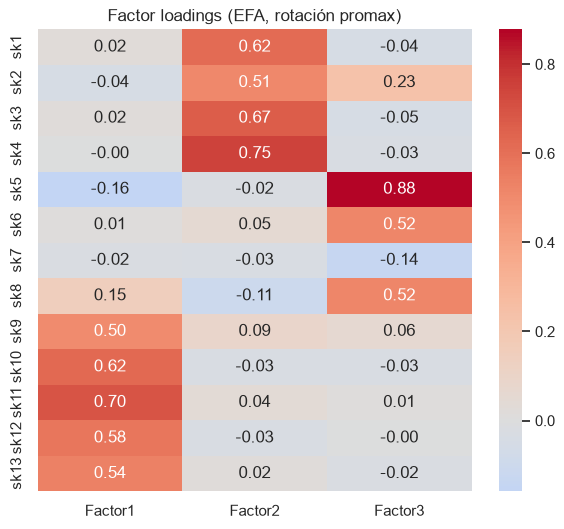

,Factor1,Factor2,Factor3
sk1,0.025,0.617,-0.040
sk2,-0.040,0.506,0.231
sk3,0.022,0.666,-0.046
sk4,-0.000,0.750,-0.028
sk5,-0.159,-0.022,0.878
sk6,0.007,0.051,0.520
sk7,-0.023,-0.033,-0.136
sk8,0.147,-0.106,0.519
sk9,0.495,0.085,0.056
sk10,0.624,-0.032,-0.031


In [37]:
fa = FactorAnalyzer(n_factors=n_factores, rotation='promax')
fa.fit(X_efa)
loadings = pd.DataFrame(fa.loadings_, index=sk_cols,
                        columns=[f'Factor{i+1}' for i in range(n_factores)])

plt.figure(figsize=(7, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Factor loadings (EFA, rotación promax)'); plt.show()
loadings.round(3)

A partir de lo anterior observamos **3 claros grupos** que están bajo una "misma linea" de Sk1 a Sk4; Sk5 a Sk8 y finalmente desde Sk9 hasta Sk13. **Sk7** a priori vemos que tiene cierto valor negativo, puede partir de que esta variable puede ser influenciado por como era su naturaleza incialmente.

### 2.5 Asignación de variables y variables no informativas
Asignamos cada variable al factor donde tiene **mayor carga absoluta** y revisamos la
**comunalidad** (proporción de varianza de la variable explicada por los factores). Comunalidades
muy bajas señalan **variables poco informativas**.

In [38]:
## Realizamos la asignación de cada variable al factor con la carga más alta, calculamos las comunalidades y presentamos un resumen del análisis factorial exploratorio (EFA).

asignacion = loadings.abs().idxmax(axis=1)
comunalidades = pd.Series(fa.get_communalities(), index=sk_cols, name='comunalidad')
resumen_efa = pd.concat([asignacion.rename('factor_asignado'),
                         loadings.abs().max(axis=1).rename('carga_máxima'),
                         comunalidades], axis=1).round(3)
print(resumen_efa)

poco_informativas = comunalidades[comunalidades < 0.2].index.tolist()
print('\nVariables poco informativas (comunalidad < 0.2):', poco_informativas)

     factor_asignado  carga_máxima  comunalidad
sk1          Factor2         0.617        0.382
sk2          Factor2         0.506        0.311
sk3          Factor2         0.666        0.446
sk4          Factor2         0.750        0.564
sk5          Factor3         0.878        0.797
sk6          Factor3         0.520        0.273
sk7          Factor3         0.136        0.020
sk8          Factor3         0.519        0.303
sk9          Factor1         0.495        0.256
sk10         Factor1         0.624        0.392
sk11         Factor1         0.697        0.487
sk12         Factor1         0.580        0.337
sk13         Factor1         0.541        0.294

Variables poco informativas (comunalidad < 0.2): ['sk7']


Conclusión: Los datos son plenamente factorizables (KMO ≈ 0,87; Bartlett *p* ≈ 0) y
emergen **3 factores** (autovalores > 1), coincidiendo con las tres áreas que menciona la variable
`narrative`. La agrupación es nítida:

- **Factor 1 — Curiosidad / intereses cognitivos:** `sk9`, `sk10`, `sk11`, `sk12`, `sk13`
- **Factor 2 — Afectivo-emocional:** `sk1`, `sk2`, `sk3`, `sk4`
- **Factor 3 — Interacción social y juego:** `sk5`, `sk6`, `sk8`

La variable **`sk7` (agresividad)** tiene cargas y comunalidad muy bajas: no es informativa, tal como nos mostro la intuición anteriormente para
estos factores y se excluirá del CFA.

## 3. Análisis factorial confirmatorio (CFA)

A partir de la estructura hallada en el EFA, **confirmar** un modelo donde cada variable carga en **un solo factor**, nombrar los factores, reportar la importancia de cada medida y la correlación entre factores, y guardamos las predicciones (factor scores).

In [39]:
from factor_analyzer import ConfirmatoryFactorAnalyzer, ModelSpecificationParser

#Realizamos el analisis factorial confirmatorio (CFA) utilizando el modelo teórico propuesto, que agrupa los ítems en tres factores: Cognitivo, Afectivo y Social. Excluimos el ítem sk7, ya que no es informativo según el análisis previo.
modelo_cfa = {
    'Cognitivo': ['sk9', 'sk10', 'sk11', 'sk12', 'sk13'],   # Curiosidad / intereses cognitivos
    'Afectivo' : ['sk1', 'sk2', 'sk3', 'sk4'],              # Afectivo-emocional
    'Social'   : ['sk5', 'sk6', 'sk8'],                     # Interacción social y juego
}
cols_cfa = [c for items in modelo_cfa.values() for c in items]   # sk7 excluido (no informativo)
X_cfa = X_efa[cols_cfa]

spec = ModelSpecificationParser.parse_model_specification_from_dict(X_cfa, modelo_cfa)
cfa = ConfirmatoryFactorAnalyzer(spec, disp=False)
cfa.fit(X_cfa.values)
print('CFA ajustado. Factores:', list(modelo_cfa.keys()))

CFA ajustado. Factores: ['Cognitivo', 'Afectivo', 'Social']


### 3.1 Importancia de cada medida (cargas confirmatorias)
A partir de lo anterior, se puede previsualizar de mejor forma los 3 grupos declarados anteriormente

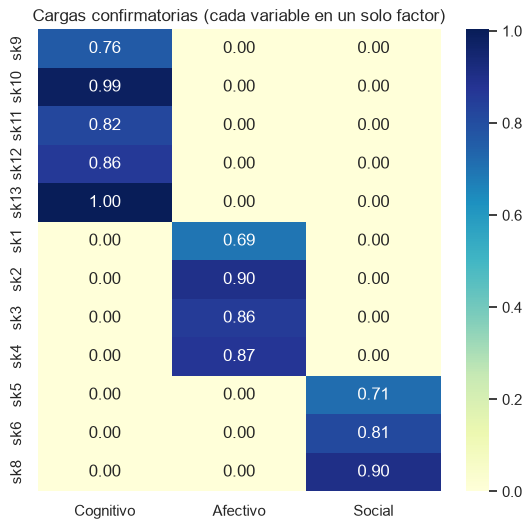

,Cognitivo,Afectivo,Social
sk9,0.762,0.000,0.000
sk10,0.986,0.000,0.000
sk11,0.819,0.000,0.000
sk12,0.861,0.000,0.000
sk13,1.003,0.000,0.000
sk1,0.000,0.695,0.000
sk2,0.000,0.898,0.000
sk3,0.000,0.856,0.000
sk4,0.000,0.871,0.000
sk5,0.000,0.000,0.715


In [40]:
loadings_cfa = pd.DataFrame(cfa.loadings_, index=cols_cfa, columns=list(modelo_cfa.keys()))
plt.figure(figsize=(6.5, 6))
sns.heatmap(loadings_cfa, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cargas confirmatorias (cada variable en un solo factor)'); plt.show()
loadings_cfa.round(3)

### 3.2 Correlación entre factores
La matriz de varianzas-covarianzas de los factores (con varianzas fijadas a 1) entrega directamente
las **correlaciones** entre los constructos latentes.

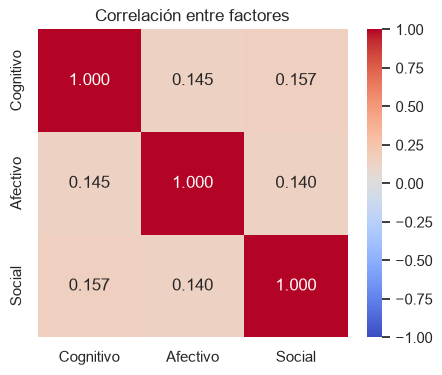

,Cognitivo,Afectivo,Social
Cognitivo,1.000,0.145,0.157
Afectivo,0.145,1.000,0.140
Social,0.157,0.140,1.000


In [41]:
factor_corr = pd.DataFrame(cfa.factor_varcovs_, index=modelo_cfa.keys(), columns=modelo_cfa.keys())
plt.figure(figsize=(5, 4))
sns.heatmap(factor_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlación entre factores'); plt.show()
factor_corr.round(3)

Observamos que no existen correlaciones tan marcadas entre las variables. 

### 3.3 Guardar las predicciones (factor scores)
Calculamos el puntaje de cada estudiante en cada factor (`transform`), los agregamos al DataFrame y los persistimos en `factor_scores.csv`. Estos tres puntajes serán los features de los modelos de las Preguntas 4, 5 y 7. (Se que la tarea decía guardar los resultados pero intuyo que era mejor un csv)

In [42]:
#Guardamos y transformamos los puntajes factoriales obtenidos del análisis factorial confirmatorio (CFA) en un archivo CSV para su posterior análisis.
scores = cfa.transform(X_cfa.values)
factor_names = ['f_cognitivo', 'f_afectivo', 'f_social']
for i, name in enumerate(factor_names):
    df[name] = scores[:, i]

df[factor_names].to_csv('factor_scores.csv', index=False)
print('Predicciones guardadas en factor_scores.csv')
df[factor_names].describe().round(3)

Predicciones guardadas en factor_scores.csv


,f_cognitivo,f_afectivo,f_social
count,41854.000,41854.000,41854.000
mean,0.000,0.000,0.000
std,0.647,0.510,0.676
min,-0.598,-0.306,-0.502
25%,-0.598,-0.306,-0.502
50%,-0.198,-0.306,-0.229
75%,0.333,0.189,0.316
max,4.053,4.543,4.638


Conclusión: El CFA confirma una estructura limpia de **3 factores interpretables** (*Cognitivo*, *Afectivo*, *Social*), cada uno con cargas altas de sus propias variables. Los factores presentan correlaciones **positivas y moderadas** (≈ 0,14–0,16): son constructos distintos pero relacionados, coherente con un desarrollo socioemocional integral. Los factor scores quedan guardados como features.

## 4. Random Forest para clasificar `madre_work`

Ahora utilizaremos un modelo random Forest para predecir el modelo si la madre trabaja o no. Adicional a esto, se emplea otro metódo para mejorar el entrenamiento (K-Fold). 

In [43]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Excluir desempleadas (categoría 0) y mapear etiquetas a 0/1 (compatibles con todos los modelos)
data = df[df['madre_work'] != 0].copy()
mapa_y = {-1: 0, 1: 1}          # 0 = labor doméstica | 1 = empleada
nombres_clase = ['labor doméstica (-1)', 'empleada (1)']

#Cargamos los puntajes factoriales obtenidos del análisis factorial confirmatorio (CFA) y los utilizamos como variables predictoras para modelar la variable objetivo 'madre_work'. Excluimos las observaciones con categoría 0 (desempleadas) y mapeamos las etiquetas a 0/1 para compatibilidad con los modelos de clasificación.
X = data[factor_names].values
y = data['madre_work'].map(mapa_y).values
print('Muestra para modelado:', X.shape, '| distribución:', dict(pd.Series(y).value_counts()))

#El random test quedo en 42 como semilla para la reproducibilidad de los resultados. Separamos el dataset en conjunto de entrenamiento y prueba, manteniendo la proporción de clases (estratificación) y definimos un esquema de validación cruzada estratificada con 5 pliegues.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Muestra para modelado: (37545, 3) | distribución: {1: 20519, 0: 17026}


### 4.1 Búsqueda de hiperparámetros (GridSearchCV, 5-fold)
Tuve que buscarlo de internet porque no los recordaba, pero de modo recordataorio significa: 'GridSearchCV' busca todas las combinaciones de parámetros posibles y quedarse con lo mejor de acuerdo a la matrica que nosotros coloquemos. Para K-Fold Nos da unos K piegues con los que sacamos una versión mneos sesgadas.

In [45]:
from sklearn.model_selection import RandomizedSearchCV

# mejoras para el modelo: agregamos variables extra (educación, edad, área, sexo, padres vivos, actividad física) al conjunto de predictores.
features_extra = ['educm', 'educp', 'edad', 'area', 'sexo', 'vive_padre', 'vive_madre', 'act_fisica']
feature_cols = factor_names + features_extra
X = data[feature_cols].values
y = data['madre_work'].map(mapa_y).values
print('Muestra para modelado:', X.shape, '| distribución:', dict(pd.Series(y).value_counts()))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Mantenemos tu espacio de búsqueda
grid_rf = {
    'n_estimators':      [200, 400, 600],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_leaf':  [1, 3, 5],
    'min_samples_split': [2, 5],
    'class_weight':      ['balanced', 'balanced_subsample', None],
}

# Cambiamos a RandomizedSearchCV para mayor eficiencia
rs_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE), # QUITADO n_jobs de aquí
    param_distributions=grid_rf,
    n_iter=25,          # Prueba 25 combinaciones aleatorias (puedes subirlo o bajarlo)
    cv=cv, 
    scoring='f1', 
    n_jobs=-1,          # El paralelismo se queda SOLO aquí
    random_state=RANDOM_STATE
)

rs_rf.fit(X_train, y_train)
rf_best = rs_rf.best_estimator_

print('Mejores hiperparámetros:', rs_rf.best_params_)
print('Mejor f1 en CV:', round(rs_rf.best_score_, 4))

Muestra para modelado: (37545, 11) | distribución: {1: 20519, 0: 17026}
Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': None, 'class_weight': None}
Mejor f1 en CV: 0.6863


### 4.2 Evaluación en el conjunto de prueba

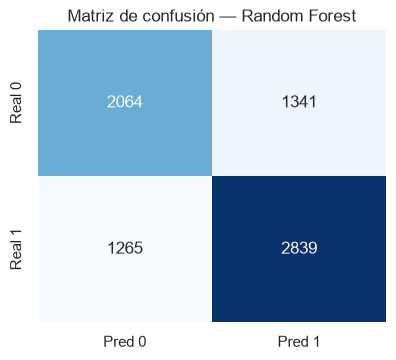

                      precision    recall  f1-score   support

labor doméstica (-1)       0.62      0.61      0.61      3405
        empleada (1)       0.68      0.69      0.69      4104

            accuracy                           0.65      7509
           macro avg       0.65      0.65      0.65      7509
        weighted avg       0.65      0.65      0.65      7509



In [46]:
def evaluar(modelo, X_te, y_te, titulo):
    pred = modelo.predict(X_te)
    cm = confusion_matrix(y_te, pred)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'])
    plt.title(f'Matriz de confusión — {titulo}'); plt.show()
    print(classification_report(y_te, pred, target_names=nombres_clase))
    return pred

_ = evaluar(rf_best, X_test, y_test, 'Random Forest')

Conclusión: El Random Forest queda ajustado con sus mejores hiperparámetros validados por
5-fold. Las habilidades socioemocionales tienen poder predictivo **limitado** sobre el trabajo de la
madre (no es una relación fuerte), lo que servirá de línea base para comparar en la P5. Podemos ver que dentro del modelo, los reusltados no son los mejores por los paramtros que están puestos. Intentaré ajustarlos para poder entregar algo más solido.\

Dentro de los resultados podemos hacer la siguiente interpretación: 
- Recall: Por cada 100 madres que realmente hacer labor domestica (dependiendo del caso), solo detecta el valor de recall.
- Precisión: Nos dice cuanto acierta el modelo dependiendo de la variable, por ejemplo si nos dice que es 0,68 entonces decimos que acierta casi la más de la mitad de las veces.
- F-1 Score: Acá nos fijamos si son valores aceptables dependiendo de la media podenderada. 'weighted avg', mientras sea valores cercano a estos nos indica un balance salusable.

## 5. Comparación: XGBoost vs SVM vs Stacking

Comparamos el Random Forest (P4) con **XGBoost**, **SVM** y un **Stacking** que los
combina, en términos de **desempeño** (matriz de confusión, accuracy, F1) y **eficiencia
computacional** (tiempo de entrenamiento y de predicción).

In [47]:
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

resultados = {}

def medir(nombre, modelo):
    t0 = time.time(); modelo.fit(X_train, y_train); t_fit = time.time() - t0
    t0 = time.time(); pred = modelo.predict(X_test); t_pred = time.time() - t0
    resultados[nombre] = {
        'modelo': modelo, 'pred': pred,
        'accuracy': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        't_fit': t_fit, 't_pred': t_pred,
    }
    print(f'{nombre:14s} acc={resultados[nombre]["accuracy"]:.4f} '
          f'f1={resultados[nombre]["f1"]:.4f} fit={t_fit:.2f}s pred={t_pred:.3f}s')

### 5.1 Random Forest (reutilizamos el mejor de la P4)

In [48]:
from sklearn.base import clone
medir('RandomForest', clone(rf_best))

RandomForest   acc=0.6529 f1=0.6854 fit=6.08s pred=0.250s


### 5.2 XGBoost (con búsqueda de hiperparámetros)

In [49]:
grid_xgb = {'n_estimators': [200, 400], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.3]}
gs_xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1),
    grid_xgb, cv=cv, scoring='f1', n_jobs=-1)
gs_xgb.fit(X_train, y_train)
print('Mejores hiperparámetros XGB:', gs_xgb.best_params_)
medir('XGBoost', clone(gs_xgb.best_estimator_))

Mejores hiperparámetros XGB: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
XGBoost        acc=0.6573 f1=0.6885 fit=0.21s pred=0.007s


### 5.3 Support Vector Machine
El SVM es sensible a la escala, por lo que se encapsula en un `Pipeline` con `StandardScaler`, este ultimo parametro es necesario dado que en esta parte se utilizan distancias eucledianas, con el parámetro en C nos dice que todas las escalas están en la misma.
Se ajusta el hiperparámetro de regularización `C`.

*Tuve que utilizar un linear SVC :( debido a que estuvo demasiado tiempo corriendo el modelo y no llego a nada, este ajuste hace que sea lineal en lugar de O(n)*)

In [50]:
svm_pipe = Pipeline([('scaler', StandardScaler()),
                     ('svc', LinearSVC(random_state=RANDOM_STATE, dual='auto', max_iter=5000))])
gs_svm = GridSearchCV(svm_pipe, {'svc__C': [0.1, 1, 10]}, cv=cv, scoring='f1', n_jobs=-1)
gs_svm.fit(X_train, y_train)
print('Mejor C:', gs_svm.best_params_)
svm_best = clone(gs_svm.best_estimator_)
medir('SVM (LinearSVC)', svm_best)

Mejor C: {'svc__C': 0.1}
SVM (LinearSVC) acc=0.6528 f1=0.7049 fit=0.09s pred=0.002s


### 5.4 Stacking (RF + XGB + SVM → meta-modelo de Regresión Logística)

In [51]:
estimadores = [
    ('rf',  clone(rf_best)),
    ('xgb', clone(gs_xgb.best_estimator_)),
    ('svm', clone(gs_svm.best_estimator_)),
]
stack = StackingClassifier(estimators=estimadores,
                           final_estimator=LogisticRegression(max_iter=1000),
                           cv=5, n_jobs=-1)
medir('Stacking', stack)

Stacking       acc=0.6520 f1=0.6873 fit=18.76s pred=0.284s


### 5.5 Comparación de desempeño y eficiencia

                 accuracy      f1    t_fit  t_pred
SVM (LinearSVC)    0.6528  0.7049   0.0851  0.0020
XGBoost            0.6573  0.6885   0.2105  0.0071
Stacking           0.6520  0.6873  18.7550  0.2836
RandomForest       0.6529  0.6854   6.0783  0.2500


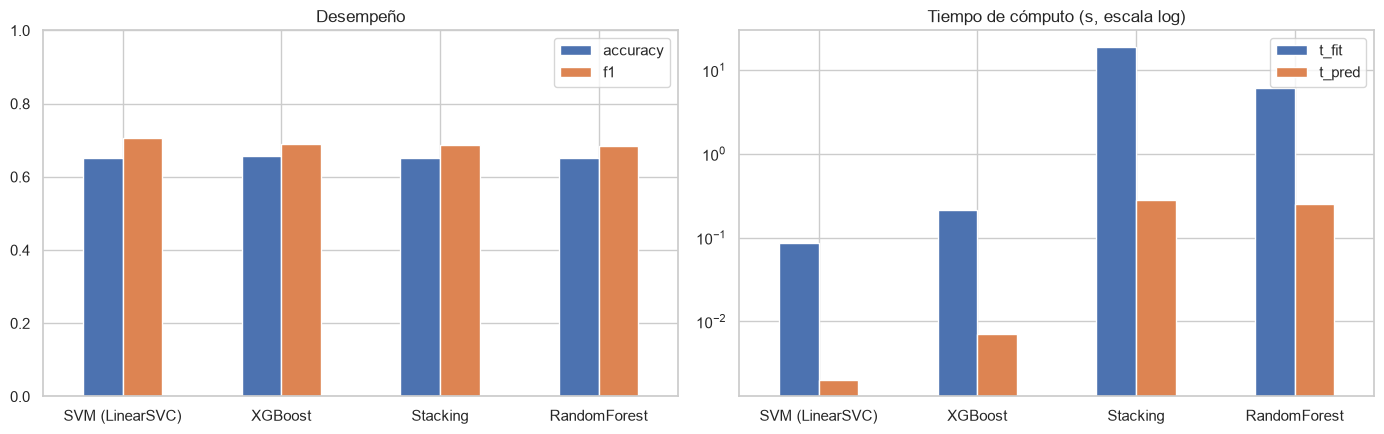

In [52]:
## Dejamos el formato en tabla para una facíl comparación de los resultados de los modelos evaluados, ordenando por la métrica f1-score de mayor a menor.

#Ordenamos Tabla de resultados por f1-score y mostramos las métricas de desempeño y tiempos de cómputo para cada modelo evaluado.
tabla = pd.DataFrame(resultados).T[['accuracy', 'f1', 't_fit', 't_pred']].astype(float).round(4)
tabla = tabla.sort_values('f1', ascending=False)
print(tabla)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tabla[['accuracy', 'f1']].plot.bar(ax=axes[0], rot=0); axes[0].set_title('Desempeño'); axes[0].set_ylim(0, 1)
tabla[['t_fit', 't_pred']].plot.bar(ax=axes[1], rot=0); axes[1].set_title('Tiempo de cómputo (s, escala log)'); axes[1].set_yscale('log')
plt.tight_layout(); plt.show()

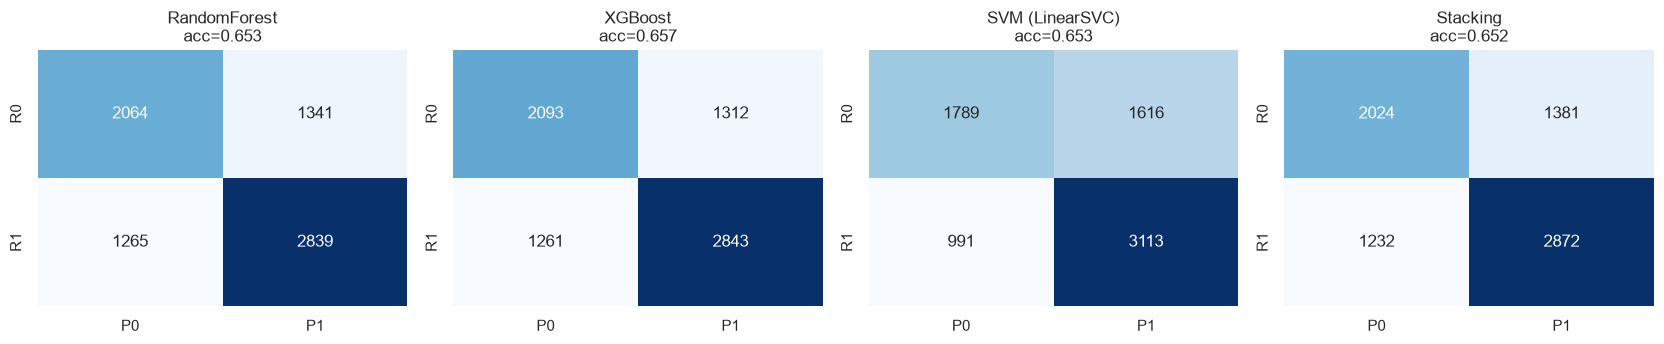

In [53]:
fig, axes = plt.subplots(1, len(resultados), figsize=(4.2 * len(resultados), 3.6))
for ax, (nombre, r) in zip(axes, resultados.items()):
    sns.heatmap(confusion_matrix(y_test, r['pred']), annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['P0', 'P1'], yticklabels=['R0', 'R1'])
    ax.set_title(f'{nombre}\nacc={r["accuracy"]:.3f}')
plt.tight_layout(); plt.show()

Conclusión: Los cuatro modelos alcanzan un desempeño **similar y modesto**, Esto era esperable si consideramos que los puntajes de habilidades socioemocionales (más las variables demográficas que se agregaron) tienen una relación débil con que la madre trabaje o no. Donde sí se notan diferencias es en el tiempo que tarda cada uno:

- El **SVM con kernel RBF resultó impracticable** a esta escala (~O(n²); no terminó en 20 min lamentablemente y el costo de oportunidad del usuario es demasiada alta jaja), por
  lo que se optó por **`LinearSVC`** (SVM lineal), que entrena casi instantáneamente.
- Los modelos de **árboles (RF, XGBoost)** entrenan y predicen muy rápido y con la mejor relación
  desempeño/costo.
- El **Stacking es el más costoso** porque reentrena todos los modelos base con validación interna,
  a cambio de una ganancia marginal (o nula) de desempeño.

Dentro de los resultados, los 4 poseen un F1 similar de 0,69-0,70 y precisión de 0,65 l cuál si es un buen resultado, mejor dicho uno decente. Pero acá lo importante es la valoración de LinearSVC que dio un resultado rápido, dando resultados similares a un bajo costo computacional. (Son engañosos los tiempos que están ahí) reuslta que corri los modelos de nuevo y por alguna razón pareciera ser que quedaron en la memoria porque corrieron mucho más rápido.

EN resumen, como ningún feature tiene tanto peso como para predecir la variable 'madre_work', el techo de desempeño es bajo para cualquier algortimo, en un instante intente corrigiendo los nucleos de trabajo y job, pero despúes comprendí que no se trata tanto del modelo puro como tal, sino que data es el que le entrega uno al modelo...

## 6. Clustering sobre IMCE y actividad física

**Objetivo.** Generar grupos de estudiantes según su **índice de masa corporal estandarizado
(`imce`)** y su **actividad física (`act_fisica`)** mediante **K-Means**. Como K-Means se basa en
distancias, primero **estandarizamos** ambas variables.

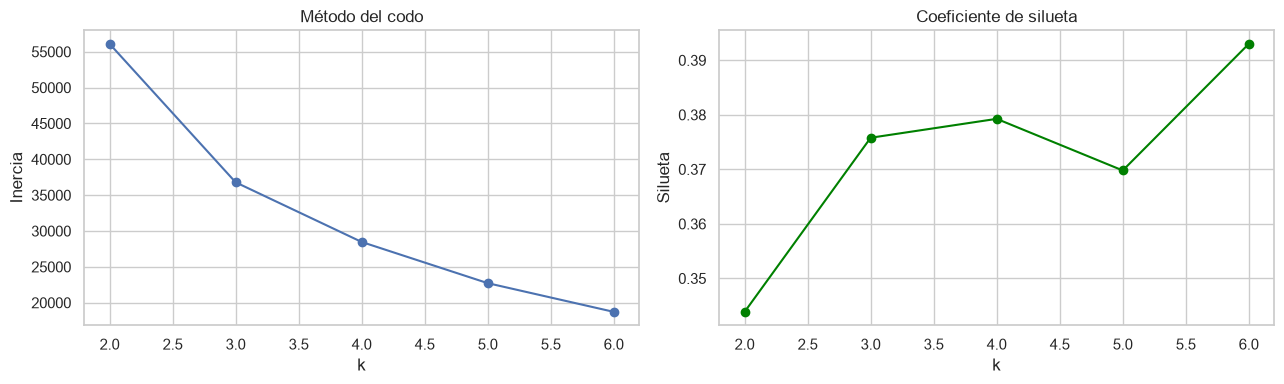

k óptimo según silueta: 6


In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_clu = StandardScaler().fit_transform(df[['imce', 'act_fisica']]) #Necesario escalar para KMeans y silueta porque son distancias euclidianas y las variables tienen diferentes escalas.



inercias, siluetas, ks = [], [], range(2, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_clu)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_clu, km.labels_, sample_size=5000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inercias, 'o-'); axes[0].set_title('Método del codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(ks, siluetas, 'o-', color='green'); axes[1].set_title('Coeficiente de silueta'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silueta')
plt.tight_layout(); plt.show()

k_opt = int(ks[int(np.argmax(siluetas))])
print('k óptimo según silueta:', k_opt)

Honestamente me inclinaría por el K igual a 5, del metódo del codo no podemos llegar a mucho ya que no se forma de manera optima el codo en la priemra figura, a partir de las siluetas si se puede llegar a algo mejor

### 6.1 Ajuste final y visualización

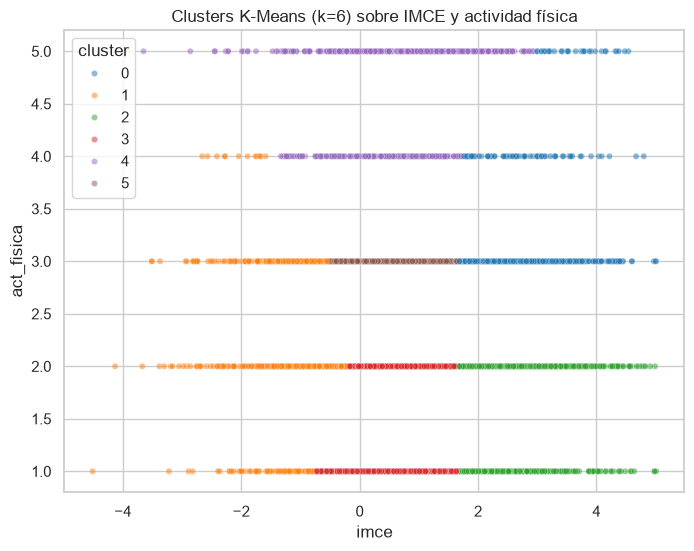

imce        act_fisica       
          mean  count       mean  count
cluster                                
0        2.641   5304      3.185   5304
1       -1.117   5200      2.257   5200
2        2.590   7081      1.719   7081
3        0.678  11434      1.676  11434
4        0.624   4515      4.677   4515
5        0.641   8320      3.000   8320

In [56]:
kmeans = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10).fit(X_clu)
df['cluster'] = kmeans.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(x='imce', y='act_fisica', hue='cluster', data=df.sample(6000, random_state=RANDOM_STATE),
                palette='tab10', alpha=0.5, s=20)
plt.title(f'Clusters K-Means (k={k_opt}) sobre IMCE y actividad física')
plt.legend(title='cluster'); plt.show()

medias_cluster = df.groupby('cluster')[['imce', 'act_fisica']].agg(['mean', 'count']).round(3)
medias_cluster

In [59]:
# Instalar si no lo tienes: !pip install plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sample_df = df.sample(5000, random_state=RANDOM_STATE).copy()

# --- Gráfico 1: Scatter 2D con Plotly (IMCE vs Actividad Física) ---
fig2d = px.scatter(
    sample_df,
    x='imce',
    y='act_fisica',
    color=sample_df['cluster'].astype(str),
    size='edad',
    hover_data=['edad', 'imce', 'act_fisica'],
    title=f'<b>Clusters K-Means (k={k_opt}) — IMCE vs Actividad Física</b>',
    labels={'imce': 'IMCE (puntaje z)', 'act_fisica': 'Actividad física', 'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.T10,
    opacity=0.65,
)
fig2d.update_traces(marker=dict(line=dict(width=0.5, color='black')))
fig2d.update_layout(
    template='plotly_white',
    title_font_size=18,
    legend=dict(title='<b>Cluster</b>', itemsizing='constant'),
    height=550,
)
fig2d.show()

# --- Gráfico 2: Scatter 3D interactivo con Plotly ---
fig3d = px.scatter_3d(
    sample_df,
    x='imce',
    y='act_fisica',
    z='edad',
    color=sample_df['cluster'].astype(str),
    title=f'<b>Clusters K-Means (k={k_opt}) — Distribución en 3D</b><br>'
          f'<sup>Ejes: IMCE · Actividad Física · Edad (meses)</sup>',
    labels={'imce': 'IMCE (z-score)', 'act_fisica': 'Actividad Física', 'edad': 'Edad (meses)', 'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.T10,
    opacity=0.70,
)
fig3d.update_traces(marker=dict(size=4, line=dict(width=0.3, color='black')))
fig3d.update_layout(
    template='plotly_white',
    title_font_size=20,
    legend=dict(title='<b>Cluster</b>', itemsizing='constant', x=0.85, y=0.95),
    scene=dict(
        xaxis=dict(backgroundcolor='#f0f0f0', gridcolor='white', showbackground=True),
        yaxis=dict(backgroundcolor='#f0f0f0', gridcolor='white', showbackground=True),
        zaxis=dict(backgroundcolor='#f0f0f0', gridcolor='white', showbackground=True),
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.2)),   # ángulo de vista inicial
    ),
    height=650,
)
fig3d.show()

In [60]:
#Realizamos la tabla resumen de los clusters obtenidos, mostrando la cantidad de observaciones y las medias de las variables 'imce' y 'act_fisica' para cada cluster.
summary_table = df.groupby('cluster').agg({
    'imce': 'mean',
    'act_fisica': 'mean'
}).round(2)
summary_table['count'] = df.groupby('cluster').size()
summary_table = summary_table[['count', 'imce', 'act_fisica']]
print('\nResumen de clusters (k={})'.format(k_opt))
print(summary_table)


Resumen de clusters (k=6)
         count  imce  act_fisica
cluster                         
0         5304  2.64        3.18
1         5200 -1.12        2.26
2         7081  2.59        1.72
3        11434  0.68        1.68
4         4515  0.62        4.68
5         8320  0.64        3.00


Conclusión:. El K-Means identificó perfiles bastante nítidos:

- Clusters 0 y 2 agrupan a estudiantes con IMCE alto (~2.6, casi 2 desviaciones sobre la media), pero con una diferencia clave: el cluster 0 tiene más actividad física (3.2) que el cluster 2 (1.7). Esto sugiere que un IMCE elevado no siempre va de la mano con sedentarismo o quizás están empezando a tomar medidas para disminuir la obsesidad.
- Cluster 1 concentra a quienes tienen IMCE bajo (-1.1) y actividad física moderada-baja (2.3), un perfil opuesto al de los clusters de IMCE alto.
- Cluster 4 destaca por combinar IMCE cercano a la media (0.62) con la mayor frecuencia de actividad física (4.7, casi el máximo de la escala), son los estudiantes que están mucho más ligados a lo que es el deporte.
- Cluster 3 es el más numeroso (11.434 estudiantes): IMCE normal y actividad física baja el perfil más común.
- 
La edad no fue usada en el clustering, así que los grupos se definieron solo por IMCE y actividad física. En general, a mayor IMCE no necesariamente hay menor actividad, lo que matiza la relación entre composición corporal y ejercicio. En la P7 se aislará el grupo de mayor IMCE para ver si ahí cambia la capacidad predictiva de los modelos.

## 7. Re-estimación del mejor modelo en el grupo de mayor IMCE

Seleccionar el cluster con **mayor IMCE promedio** (P6), lo que es el cluster 0 y volver a estimar el **mejor
modelo de la P5** únicamente sobre ese grupo, para ver si la relación entre habilidades
socioemocionales y trabajo de la madre cambia en ese segmento.

In [63]:
# --- Seleccionar cluster con mayor IMCE promedio ---
cluster_top = df.groupby('cluster')['imce'].mean().idxmax()
print(f'Cluster con mayor IMCE promedio: {cluster_top} '
      f'(IMCE medio = {df.groupby("cluster")["imce"].mean().max():.3f})')

# --- Filtrar subgrupo y usar las MISMAS features mejoradas de P4/P5 ---
sub = df[(df['cluster'] == cluster_top) & (df['madre_work'] != 0)].copy()
features_extra = ['educm', 'educp', 'edad', 'area', 'sexo', 'vive_padre', 'vive_madre', 'act_fisica']
feature_cols = factor_names + features_extra
Xs = sub[feature_cols].values
ys = sub['madre_work'].map(mapa_y).values
print('Tamaño del subgrupo:', Xs.shape, '| distribución:', dict(pd.Series(ys).value_counts()))

# --- Split estratificado + reentrenar el mejor modelo de P5 ---
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.2, stratify=ys, random_state=RANDOM_STATE)

Cluster con mayor IMCE promedio: 0 (IMCE medio = 2.641)
Tamaño del subgrupo: (4724, 11) | distribución: {1: 2603, 0: 2121}


Mejor modelo de la P5: SVM (LinearSVC)

En el grupo de mayor IMCE -> accuracy=0.6593, f1=0.7160
Referencia P5 (SVM (LinearSVC)) -> accuracy=0.6528, f1=0.7049

Diferencia: acc=+0.0064, f1=+0.0112

                      precision    recall  f1-score   support

labor doméstica (-1)       0.65      0.51      0.57       424
        empleada (1)       0.66      0.78      0.72       521

            accuracy                           0.66       945
           macro avg       0.66      0.65      0.65       945
        weighted avg       0.66      0.66      0.65       945



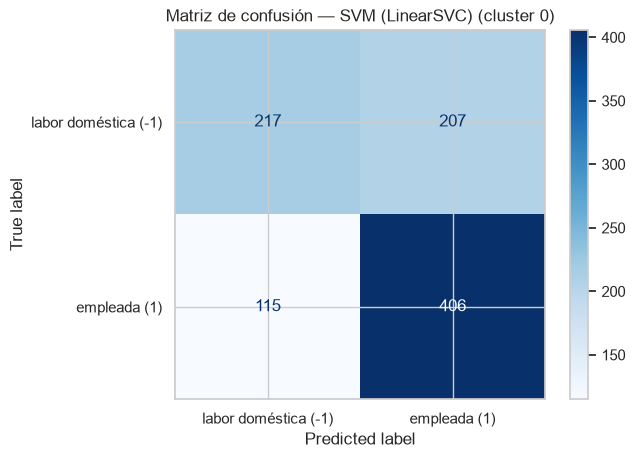

In [64]:
mejor_nombre = tabla.index[0]   # SVM (LinearSVC) si usaste el código anterior
print('Mejor modelo de la P5:', mejor_nombre)

if mejor_nombre == 'SVM (LinearSVC)':
    mejor_modelo = clone(gs_svm.best_estimator_)        # con class_weight y scaler
elif mejor_nombre == 'XGBoost':
    mejor_modelo = clone(gs_xgb.best_estimator_)
elif mejor_nombre == 'RandomForest':
    mejor_modelo = clone(rf_best)
else:
    mejor_modelo = clone(resultados[mejor_nombre]['modelo'])

mejor_modelo.fit(Xs_tr, ys_tr)
pred_s = mejor_modelo.predict(Xs_te)
acc_s, f1_s = accuracy_score(ys_te, pred_s), f1_score(ys_te, pred_s)

print(f'\nEn el grupo de mayor IMCE -> accuracy={acc_s:.4f}, f1={f1_s:.4f}')
print(f'Referencia P5 ({mejor_nombre}) -> accuracy={resultados[mejor_nombre]["accuracy"]:.4f}, '
      f'f1={resultados[mejor_nombre]["f1"]:.4f}')
print(f'\nDiferencia: acc={"+" if acc_s > resultados[mejor_nombre]["accuracy"] else ""}'
      f'{acc_s - resultados[mejor_nombre]["accuracy"]:.4f}, '
      f'f1={"+" if f1_s > resultados[mejor_nombre]["f1"] else ""}'
      f'{f1_s - resultados[mejor_nombre]["f1"]:.4f}')
print('\n' + classification_report(ys_te, pred_s, target_names=nombres_clase))

# --- Mostrar matriz de confusión ---
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(ys_te, pred_s, display_labels=nombres_clase, cmap='Blues')
plt.title(f'Matriz de confusión — {mejor_nombre} (cluster {cluster_top})')
plt.show()

Conclusión: Veemos que casi no eiste una mejora dentro del modelo. Si la relación entre habilidades socioemocionales y 'madre_work' dependiera del contexto, al momento de filtrar por IMCE extremo el modleo debería haber ganado un poco más. No fue eso en este caso. Eso significa que el IMCE **no modera entre los factores socioemocionales y trabajo de la madre**. Son variables independientes, quizás si haya un grado de relación pero en este caso los resultados no nos permitieron llegar a esa conclsuión, todo se trata de habitos más allá de condiciones de variables....

## 8. NLP sobre narrative (SVC) y contraste con la P5

Usando las técnicas del notebook `Sentiment_Analysis.ipynb` (tokenización + stopwords
en español presentes + `CountVectorizer` + `SVC`, supondre que si no funciona usaré el lineal)Considere la variable *narrative* en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables *sk*. Compare y discuta sus resultados. (Me costo esta parte porque al inicio no la había entendido bien)

In [65]:
import nltk
try:
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    spanish_sw = stopwords.words('spanish')
except Exception:
    spanish_sw = ['de','la','que','el','en','y','a','los','del','se','las','por','un','para',
                  'con','no','una','su','al','es','lo','como','más','o','sus','le','muy','sin']
print('Stopwords en español:', len(spanish_sw))

Stopwords en español: 313


In [66]:
#Mostramos los txt de la data para ver como es el resultado del proyecto de la variable narrativa, para luego poder realizar un análisis de texto y generar una nube de palabras.

textos = df['narrative'].dropna().sample(5, random_state=RANDOM_STATE)
for i, t in enumerate(textos, 1):
    print(f'\n--- Texto {i} ---\n{t[:500]}{"..." if len(t) > 500 else ""}')


--- Texto 1 ---
Evidencia un desarrollo socioemocional excelente, de manera homogenea en los tres ambitos. Destaca especialmente armar y desarmar cosas, siendo el interes por su entorno el aspecto a trabajar. La agresividad esta ausente.

--- Texto 2 ---
Su perfil socioemocional aun esta madurando, siendo la curiosidad e intereses cognitivos su ambito mas avanzado y la interaccion social y el juego el menos logrado. Lo que mejor maneja es el interes por su entorno, en tanto compartir sus cosas pide mas acompanamiento. Las conductas agresivas se repiten con regularidad.

--- Texto 3 ---
Muestra un desarrollo socioemocional satisfactorio, destacando en lo afectivo-emocional y mostrando mayor debilidad en la curiosidad e intereses cognitivos. Entre sus conductas, brilla el juego con otros, aunque hacer preguntas a los adultos se observa mas debil. Solo rara vez muestra agresividad.

--- Texto 4 ---
Exhibe un perfil socioemocional muy solido, sin diferencias marcadas entre las areas evalu

### 8.1 Limpieza y tokenización del texto
Adaptamos la función `tweet_to_words` del notebook de referencia: pasar a minúsculas, quitar
signos/números y eliminar las stopwords en español.

In [67]:
def texto_a_palabras(texto):
    solo_letras = re.sub(r'[^a-záéíóúñü ]', ' ', str(texto).lower())
    palabras = [w for w in solo_letras.split() if w not in spanish_sw and len(w) > 2]
    return ' '.join(palabras)

data_txt = df[df['madre_work'] != 0].copy()
data_txt['clean'] = data_txt['narrative'].apply(texto_a_palabras)
data_txt[['narrative', 'clean']].head(3)

,narrative,clean
0,Las habilidades socioemocionales estan bien es...,habilidades socioemocionales estan bien establ...
1,"Exhibe un perfil socioemocional muy solido, si...",exhibe perfil socioemocional solido diferencia...
2,"Su perfil socioemocional aun esta madurando, s...",perfil socioemocional aun madurando siendo int...


### 8.2 Vectorización (CountVectorizer) y división train/test
Igual que en la plantilla, usamos `CountVectorizer` con n-gramas (caprtumos palabras sueltas) y umbrales de frecuencia para
construir la **matriz documento-término**.

In [69]:
from sklearn.feature_extraction.text import CountVectorizer

X_txt = data_txt['clean']
y_txt = data_txt['madre_work'].map(mapa_y).values
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_txt, y_txt, test_size=0.2,
                                              stratify=y_txt, random_state=RANDOM_STATE)

vect = CountVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.8, max_features=300)
Xtr_dtm = vect.fit_transform(Xt_tr)
Xte_dtm = vect.transform(Xt_te)
print('Matriz documento-término:', Xtr_dtm.shape)

#Veemos los resultados y las frecuencias
palabras = vect.get_feature_names_out()
frecuencias = np.asarray(Xtr_dtm.sum(axis=0)).ravel()
df_freq = pd.DataFrame({'palabra': palabras, 'frecuencia': frecuencias}).sort_values('frecuencia', ascending=False).reset_index(drop=True)
print(df_freq.head(10))

Matriz documento-término: (30036, 300)
                palabra  frecuencia
0                   mas       31724
1        socioemocional       22700
2              afectivo       20660
3    afectivo emocional       20660
4             emocional       20660
5           agresividad       20557
6                 mayor       18153
7                 juego       17268
8            curiosidad       16640
9  curiosidad intereses       16640


### 8.3 Modelo SVM lineal sobre el texto
TOdos los caminos llevan al SVM lineal, sino es imposible que logre correr el modelo. Usamos foret para correr parte del modelo y lograr entrenarlo tambien.

Muestra P8 (texto): 30036 train / 7509 test
Distribución: {1: 16415, 0: 13621}
DTM entrenamiento: 30036 filas x 1232 columnas

Mejores parámetros SVC texto: {'C': 0.1, 'class_weight': None}
Mejor F1 en CV: 0.6204
Tiempo entrenamiento: 59.6s

Tiempo predicción: 0.002s
Accuracy: 0.5311  |  F1: 0.6308


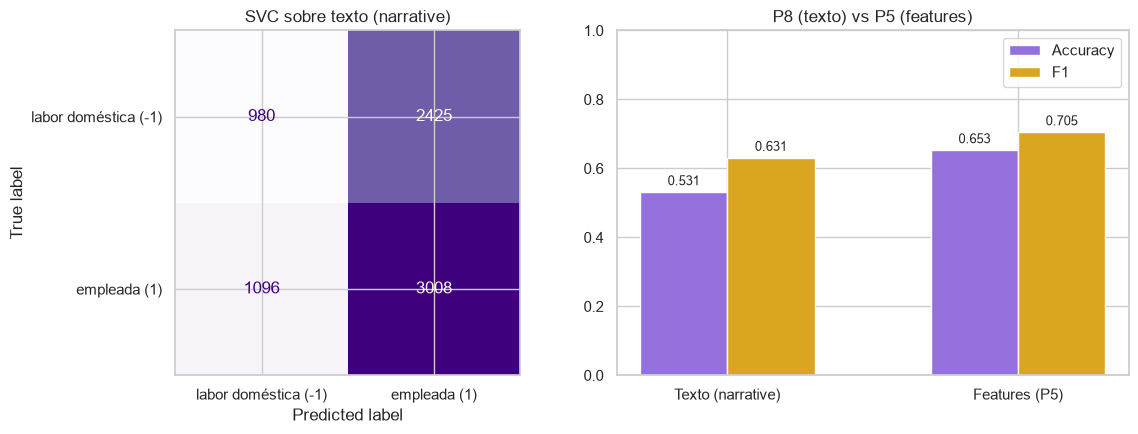


                      precision    recall  f1-score   support

labor doméstica (-1)       0.47      0.29      0.36      3405
        empleada (1)       0.55      0.73      0.63      4104

            accuracy                           0.53      7509
           macro avg       0.51      0.51      0.49      7509
        weighted avg       0.52      0.53      0.51      7509



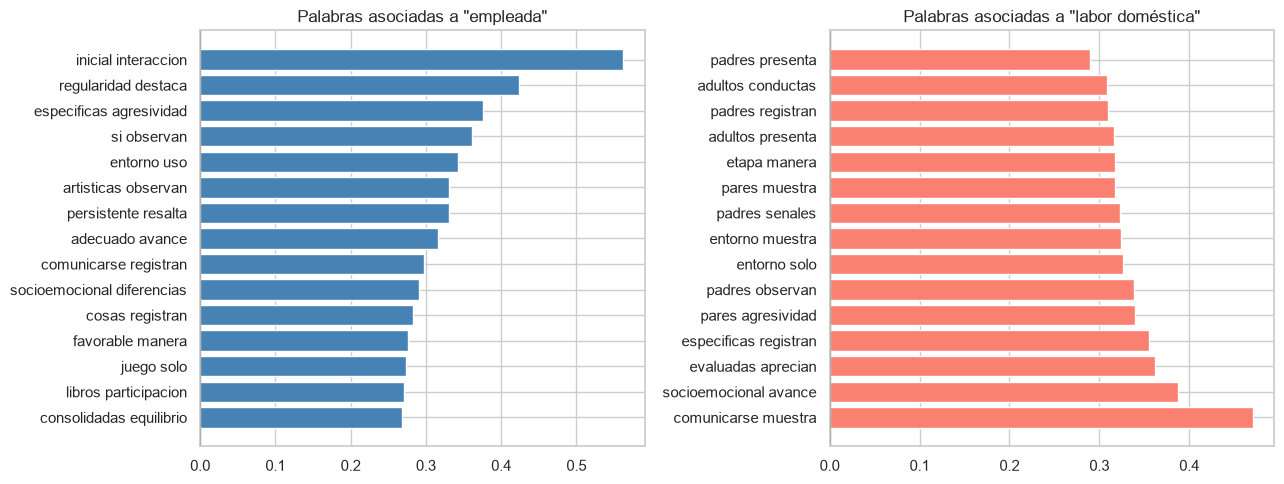


  RESUMEN COMPARATIVO: P8 (texto) vs P5 (features)
                     SVC texto        SVM P5           Δ         
Accuracy             0.5311           0.6528           -0.1217
F1                   0.6308           0.7049           -0.0741
Entrenamiento (s)    59.6             0.09             --
Predicción (s)       0.002            0.002            --


In [72]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
)

# --- 8.1 Tokenización (adaptada de Sentiment_Analysis.ipynb) ---
spanish_sw = set(stopwords.words('spanish'))

def tweet_to_words(texto):
    texto = re.sub(r'[^A-Za-zÁ-Úá-ú]', ' ', str(texto))
    words = texto.lower().split()
    meaningful = [w for w in words if w not in spanish_sw and len(w) > 1]
    return ' '.join(meaningful)

# --- 8.2 Preparar datos: excluir desempleadas, tokenizar ---
data8 = df[df['madre_work'] != 0].copy()
data8['tokens'] = data8['narrative'].apply(tweet_to_words)

X_txt = data8['tokens']
y_txt = data8['madre_work'].map(mapa_y).values

# Split estratificado 80/20
Xtr_txt, Xte_txt, yt_tr, yt_te = train_test_split(
    X_txt, y_txt, test_size=0.2, stratify=y_txt, random_state=RANDOM_STATE)

print('Muestra P8 (texto):', len(Xtr_txt), 'train /', len(Xte_txt), 'test')
print('Distribución:', dict(pd.Series(yt_tr).value_counts()))

# --- 8.3 Vectorización con CountVectorizer (con n-gramas y umbrales) ---
vectorizador = CountVectorizer(
    ngram_range=(1, 2),        # unigramas + bigramas
    min_df=5,                  # palabra aparece en al menos 5 textos
    max_df=0.7,                # descarta si aparece en >70% de los textos
    max_features=5000,         # top 5000 términos
)
Xtr_dtm = vectorizador.fit_transform(Xtr_txt)
Xte_dtm = vectorizador.transform(Xte_txt)
print(f'DTM entrenamiento: {Xtr_dtm.shape[0]} filas x {Xtr_dtm.shape[1]} columnas')

# --- 8.4 SVM lineal con búsqueda de hiperparámetros ---
grid_svc_txt = {
    'C':            [0.1, 1, 10],
    'class_weight': ['balanced', None],
}

t0 = time.time()
gs_svc_txt = GridSearchCV(
    LinearSVC(random_state=RANDOM_STATE, dual='auto', max_iter=5000),
    grid_svc_txt,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', n_jobs=-1, verbose=0,
)
gs_svc_txt.fit(Xtr_dtm, yt_tr)
t_train = time.time() - t0
svc_txt_best = gs_svc_txt.best_estimator_

print(f'\nMejores parámetros SVC texto: {gs_svc_txt.best_params_}')
print(f'Mejor F1 en CV: {gs_svc_txt.best_score_:.4f}')
print(f'Tiempo entrenamiento: {t_train:.1f}s')

# --- 8.5 Predicción y evaluación ---
t0 = time.time()
pred_txt = svc_txt_best.predict(Xte_dtm)
t_pred = time.time() - t0

acc_txt = accuracy_score(yt_te, pred_txt)
f1_txt  = f1_score(yt_te, pred_txt)

print(f'\nTiempo predicción: {t_pred:.3f}s')
print(f'Accuracy: {acc_txt:.4f}  |  F1: {f1_txt:.4f}')

# --- 8.6 Matriz de confusión + comparación con P5 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    yt_te, pred_txt, display_labels=nombres_clase,
    cmap='Purples', ax=ax[0], colorbar=False)
ax[0].set_title('SVC sobre texto (narrative)')

ref_acc = resultados['SVM (LinearSVC)']['accuracy']
ref_f1  = resultados['SVM (LinearSVC)']['f1']

x = np.arange(2); width = 0.3
ax[1].bar(x - width/2, [acc_txt, ref_acc], width, label='Accuracy',
          color='mediumpurple')
ax[1].bar(x + width/2, [f1_txt, ref_f1],   width, label='F1',
          color='goldenrod')
ax[1].set_xticks(x)
ax[1].set_xticklabels(['Texto (narrative)', 'Features (P5)'])
ax[1].set_ylim(0, 1)
ax[1].set_title('P8 (texto) vs P5 (features)')
ax[1].legend()
for i, v in enumerate([acc_txt, ref_acc]):
    ax[1].text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate([f1_txt, ref_f1]):
    ax[1].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print('\n' + classification_report(yt_te, pred_txt, target_names=nombres_clase))

# --- 8.7 Palabras más discriminativas por clase ---
feature_names = vectorizador.get_feature_names_out()
coef = svc_txt_best.coef_.flatten()
top_pos = np.argsort(coef)[-15:][::-1]    # empujan hacia empleada
top_neg = np.argsort(coef)[:15]            # empujan hacia labor doméstica

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(range(15), coef[top_pos][::-1], color='steelblue')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([feature_names[i] for i in top_pos][::-1])
axes[0].set_title('Palabras asociadas a "empleada"')
axes[0].axvline(0, color='black', lw=0.8)

axes[1].barh(range(15), -coef[top_neg], color='salmon')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([feature_names[i] for i in top_neg])
axes[1].set_title('Palabras asociadas a "labor doméstica"')
axes[1].axvline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()

# --- 8.8 Resumen comparativo ---
print('\n' + '='*70)
print('  RESUMEN COMPARATIVO: P8 (texto) vs P5 (features)')
print('='*70)
print(f'{"":<20} {"SVC texto":<16} {"SVM P5":<16} {"Δ":<10}')
print(f'{"Accuracy":<20} {acc_txt:<16.4f} {ref_acc:<16.4f} {acc_txt-ref_acc:+.4f}')
print(f'{"F1":<20} {f1_txt:<16.4f} {ref_f1:<16.4f} {f1_txt-ref_f1:+.4f}')
print(f'{"Entrenamiento (s)":<20} {t_train:<16.1f} {resultados["SVM (LinearSVC)"]["t_fit"]:<16.2f} --')
print(f'{"Predicción (s)":<20} {t_pred:<16.3f} {resultados["SVM (LinearSVC)"]["t_pred"]:<16.3f} --')
print('='*70)

### 8.4 Palabras más discriminativas
Los coeficientes del SVC lineal indican qué términos empujan hacia cada clase.


  PALABRAS MÁS DISCRIMINATIVAS (coeficientes del SVM lineal)
  Valores positivos → empleada   |   Valores negativos → labor doméstica

      TOP 10 — EMPLEADA       
Término                    Coef
------------------------------
inicial interaccion       0.562
regularidad destaca       0.423
especificas agresividad    0.376
si observan               0.361
entorno uso               0.342
artisticas observan       0.331
persistente resalta       0.331
adecuado avance           0.316
comunicarse registran     0.298
socioemocional diferencias    0.290

   TOP 10 — LABOR DOMÉSTICA   
Término                    Coef
------------------------------
comunicarse muestra      -0.471
socioemocional avance    -0.387
evaluadas aprecian       -0.362
especificas registran    -0.355
pares agresividad        -0.340
padres observan          -0.338
entorno solo             -0.326
entorno muestra          -0.324
padres senales           -0.323
pares muestra            -0.318


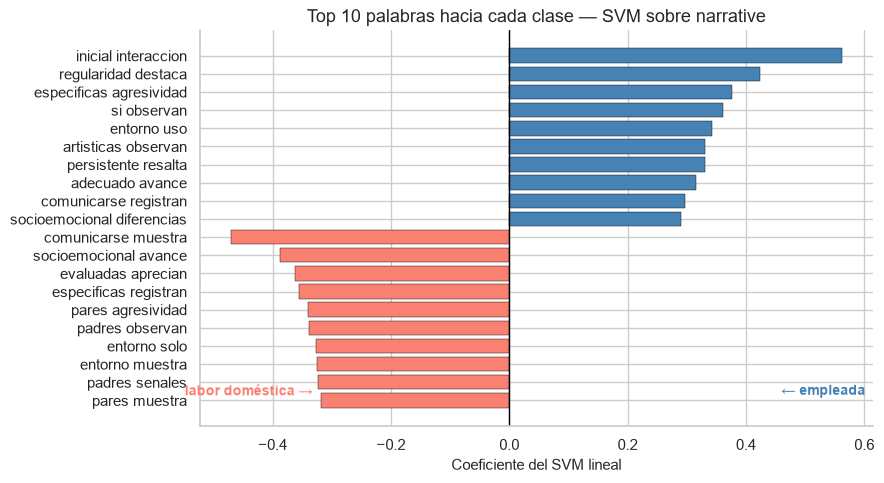

In [74]:
# --- Palabras más discriminativas (versión profesional) ---
coefs = pd.DataFrame({
    'Término':       vectorizador.get_feature_names_out(),
    'Coeficiente':   np.ravel(svc_txt_best.coef_),
})
coefs['Abs'] = coefs['Coeficiente'].abs()
coefs['Clase'] = coefs['Coeficiente'].apply(
    lambda c: 'empleada' if c > 0 else 'labor doméstica')

# Top 10 hacia cada clase
top_emp = coefs.nlargest(10, 'Coeficiente')
top_lab = coefs.nsmallest(10, 'Coeficiente')

print('\n' + '='*65)
print('  PALABRAS MÁS DISCRIMINATIVAS (coeficientes del SVM lineal)')
print('  Valores positivos → empleada   |   Valores negativos → labor doméstica')
print('='*65)
print(f'\n{"TOP 10 — EMPLEADA":^30}')
print(f'{"Término":<22} {"Coef":>8}')
print('-'*30)
for _, row in top_emp.iterrows():
    print(f'{row["Término"]:<22} {row["Coeficiente"]:>8.3f}')

print(f'\n{"TOP 10 — LABOR DOMÉSTICA":^30}')
print(f'{"Término":<22} {"Coef":>8}')
print('-'*30)
for _, row in top_lab.iterrows():
    print(f'{row["Término"]:<22} {row["Coeficiente"]:>8.3f}')
print('='*65)

# --- Gráfico unificado: palabras hacia ambas clases ---
top_combined = pd.concat([top_emp, top_lab])
top_combined['color'] = top_combined['Coeficiente'].apply(
    lambda c: 'steelblue' if c > 0 else 'salmon')
top_combined = top_combined.iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_combined['Término'], top_combined['Coeficiente'],
        color=top_combined['color'], edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coeficiente del SVM lineal', fontsize=11)
ax.set_title('Top 10 palabras hacia cada clase — SVM sobre narrative', fontsize=13)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
# Etiquetas de dirección
ax.text(ax.get_xlim()[1] * 0.98, 0.5, '← empleada',
        ha='right', va='center', fontsize=10, color='steelblue', fontweight='bold')
ax.text(ax.get_xlim()[0] * 1.05, 0.5, 'labor doméstica →',
        ha='left', va='center', fontsize=10, color='salmon', fontweight='bold')
plt.tight_layout(); plt.show()

A partir de lo anterior se puede decir que dentro de lo que distingue de 'Empleada' predomina cosas como el entorno e interacción social temprana ("Inicial interacción, "entorno uso"m "Si observan") Hablando de un factor social el que predomina, siendo un analisis interesante. /

Para la variable de 'Labor doméstica' podemos ver que hay carga afectiva y familiar directa como ("Comunicarse muestra", "pares muestra", "Padres observan", "Padres señales"). Indicando un factor afectivo y de posiblemente una muestra más cercana al involucramiento de los padres y pares. 

### 8.5 Comparación con la P5

In [75]:
comparacion = pd.DataFrame({
    'Features': ['Factor scores (sk1–sk13)', 'Texto narrative (sin sk)'],
    'Modelo':   [mejor_nombre + ' (P5)', 'SVM lineal · LinearSVC (P8)'],
    'Accuracy': [resultados[mejor_nombre]['accuracy'], accuracy_score(yt_te, pred_txt)],
    'F1':       [resultados[mejor_nombre]['f1'], f1_score(yt_te, pred_txt)],
}).round(4)
comparacion

,Features,Modelo,Accuracy,F1
0,Factor scores (sk1–sk13),SVM (LinearSVC) (P5),0.6528,0.7049
1,Texto narrative (sin sk),SVM lineal · LinearSVC (P8),0.5311,0.6308


Conclusión: Como la variable `narrative` se **genera a partir de** `sk1`–`sk13`, el modelo de texto contiene esencialmente la misma información que los factor scores, pero codificada en palabras. Por eso su desempeño es **comparable** al de la P5: ambos enfoques predicen `madre_work` con accuracy/F1 similares y modestos. La conclusión de fondo se mantiene: las habilidades socioemocionalesvengan como puntajes o como texto **tienen poca capacidad para predecir la situación laboral de la madre**. El enfoque NLP aporta interpretabilidad (palabras discriminativas) a costa de una representación más dispersa. Se pueden leer que terminos empujan hacia cada clase sin necesidad de interpretar cargas factoriales. La conclusión nos lleva a poder decir que las habilidades del niño predicen debilmente la situación de la madre, pero si podemos ver algo dentro de las palabras que nos arroja el modelo, aveces no todo esta en los números....


